# Import & Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")

df = pd.read_csv("clean_report.csv")
df.head()

,name,age,marks,city,grade,status
0,Ravi,21.0,78.0,Hyderabad,B,pass
1,Priya,22.0,85.0,Chennai,B,pass
2,Kiran,20.0,92.0,Mumbai,A,pass
3,Anita,23.0,60.0,Delhi,C,pass
4,Suresh,21.0,74.0,Pune,C,pass


# Marks Distribution

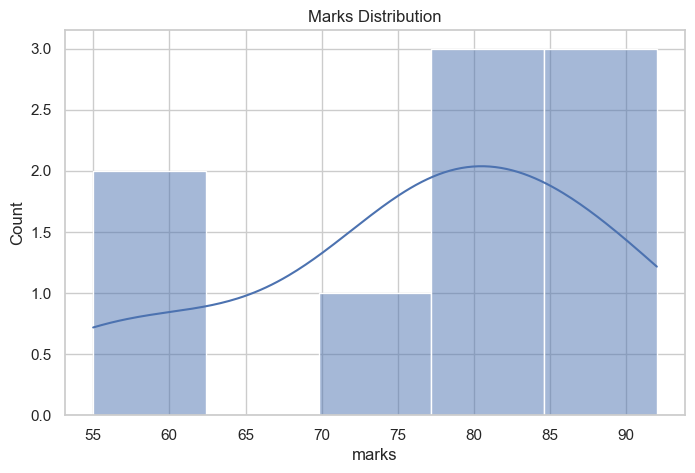

In [2]:
plt.figure(figsize=(8,5))
sns.histplot(df["marks"], kde=True)
plt.title("Marks Distribution")
plt.show()

## Key Insight
- The histogram shows that most students scored between 70 and 90 marks.

# Marks by City

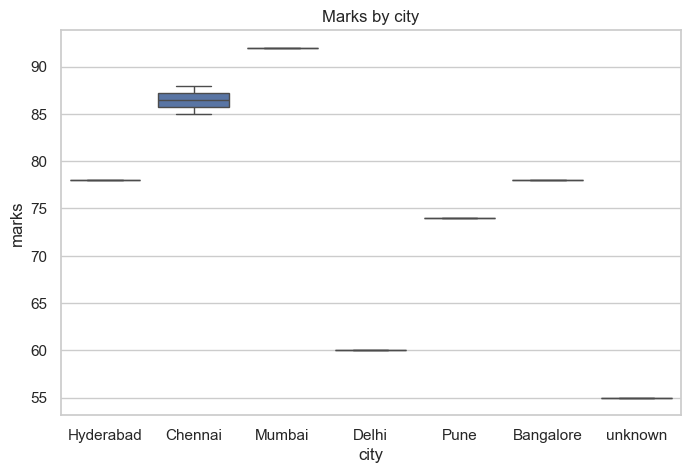

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="city", y="marks")
plt.title("Marks by city")
plt.show()

## Key Insight
- The box plot indicates there are no major outliers in the marks data.

# Grade Counts

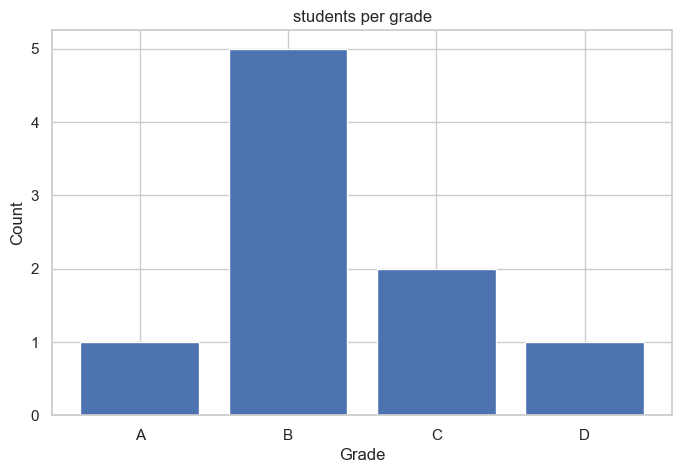

In [12]:
grade_counts = df["grade"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(grade_counts.index, grade_counts.values)
plt.title("students per grade")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.show()

## Key Insight
- The bar chart shows that Mumbai has the highest average marks, while unknown/other categories have lower averages.

# Marks vs Rank

Index(['name', 'age', 'marks', 'city', 'grade', 'status', 'rank'], dtype='object')


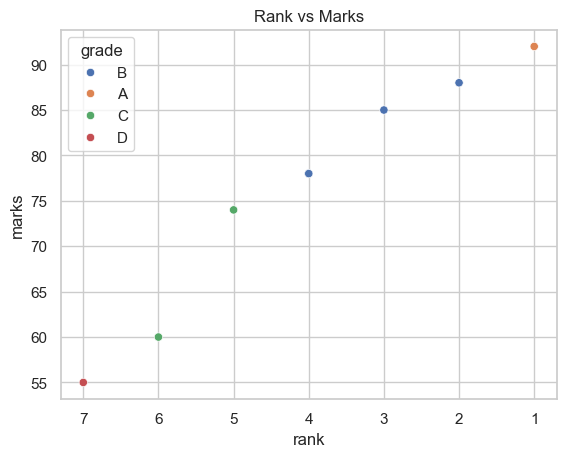

In [28]:
print(df.columns)
df["rank"] = df["marks"].rank(method="dense", ascending=False)
sns.scatterplot(data=df, x="rank", y="marks", hue="grade")
plt.gca().invert_xaxis()
plt.title("Rank vs Marks")
plt.show()

## Key Insight
- scatter plot suggests that students with better ranks generally have higher marks.

# Correlation Heatmap

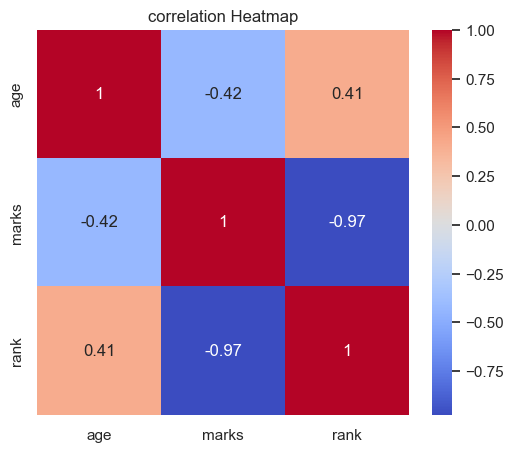

In [31]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(6,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("correlation Heatmap")
plt.show()

## Key Insight
- The heatmap shows a strong relationship between marks and rank.

# Interactive City Performance

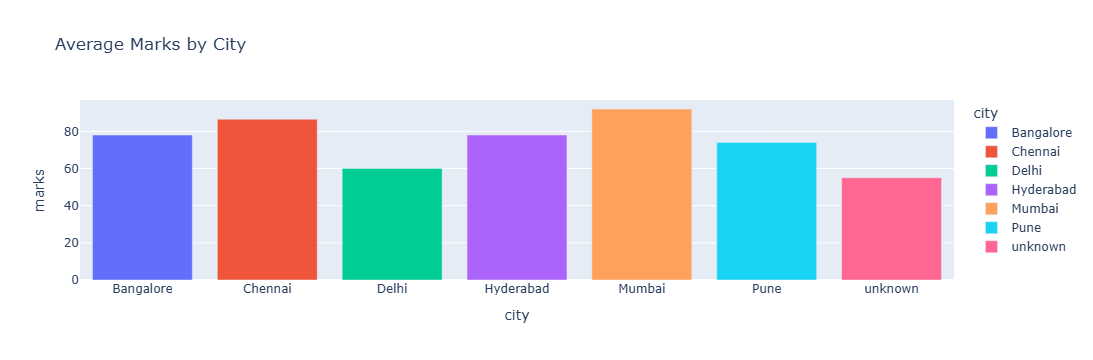

In [32]:
city_avg = df.groupby("city")["marks"].mean().reset_index()

fig = px.bar(
    city_avg,
    x="city",
    y="marks",
    color="city",
    title="Average Marks by City"
)

fig.show()

## Key Insight
- The interactive chart allows easy comparison of student performance across different grades.

# Key Insights Summary

- Most students scored between 70 and 90 marks.
- No significant outliers were found in the marks data.
- Student performance varies across different cities.
- Marks and rank are strongly related; higher marks lead to better ranks.
- The correlation analysis confirmed the relationship between marks and rank.
- Interactive visualizations improved data exploration and comparison.

# percentage distribution of grades

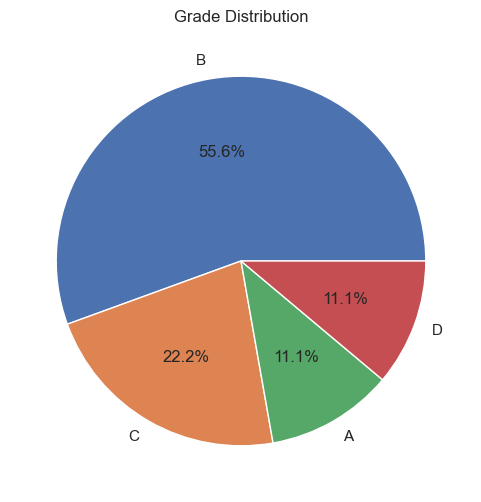

In [35]:
grade_counts = df["grade"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    grade_counts,
    labels=grade_counts.index,
    autopct="%1.1f%%"
)

plt.title("Grade Distribution")
plt.show()

# Extension Explanation
I added a Pie Chart to visualize the percentage distribution of grades. This chart helps quickly understand which grade category has the highest
share of students.

# Save all charts as PNG

In [38]:
# Save All Charts as PNG (300 DPI)

import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1 - Histogram
plt.figure(figsize=(8,5))
sns.histplot(df["marks"], kde=True)
plt.title("Marks Distribution")
plt.savefig("chart1_histogram.png", dpi=300, bbox_inches="tight")
plt.close()

# Chart 2 - Box Plot
plt.figure(figsize=(8,5))
sns.boxplot(y=df["marks"])
plt.title("Marks by city")
plt.savefig("chart2_boxplot.png", dpi=300, bbox_inches="tight")
plt.close()

# Chart 3 - Bar Chart
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="city", y="marks")
plt.title("student per ggrade")
plt.savefig("chart3_barchart.png", dpi=300, bbox_inches="tight")
plt.close()

# Chart 4 - Scatter Plot
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="rank", y="marks")
plt.title("Marks vs Rank")
plt.savefig("chart4_scatterplot.png", dpi=300, bbox_inches="tight")
plt.close()

# Chart 5 - Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("chart5_heatmap.png", dpi=300, bbox_inches="tight")
plt.close()

print("All 5 PNG charts saved successfully!")

All 5 PNG charts saved successfully!


# Save Plotly Chart as HTML

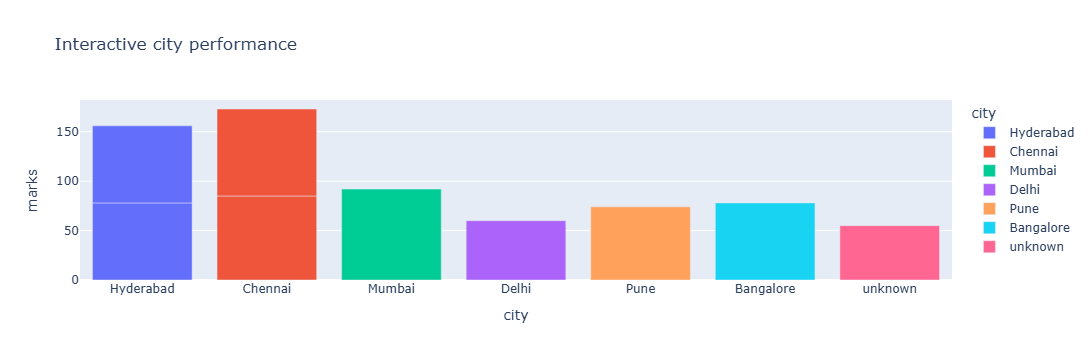

In [40]:
import plotly.express as px

fig = px.bar(
    df,
    x="city",
    y="marks",
    color="city",
    title="Interactive city performance"
)

fig.show()

fig.write_html("interactive.html")